In [1]:
import sqlite3
import pandas as pd
from pathlib import Path
import plotly.express as px

db_path = Path.cwd().parent / "tempo_dev.db"
conn = sqlite3.connect(db_path)

samples = pd.read_sql("SELECT * FROM health_samples ORDER BY start_date DESC LIMIT 5", conn)
samples

,uuid,type,quantity,start_date,end_date,inserted_at,updated_at
0,28142287-69EB-4829-8BD7-76F786399FC5,HKQuantityTypeIdentifierHeartRate,61.000000,2026-01-19T13:15:28Z,2026-01-19T13:15:28Z,2026-01-19T13:17:45,2026-01-19T13:17:45
1,1DD1F457-04B8-475A-9D5C-0205D0998ECC,HKQuantityTypeIdentifierHeartRate,56.000000,2026-01-19T13:10:22Z,2026-01-19T13:10:22Z,2026-01-19T13:17:45,2026-01-19T13:17:45
2,A41CBCFD-5D9C-4CD7-86C2-59ED1AA03785,HKQuantityTypeIdentifierHeartRate,66.000000,2026-01-19T13:08:33Z,2026-01-19T13:08:33Z,2026-01-19T13:17:45,2026-01-19T13:17:45
3,D67EE2C7-BBC0-4426-AAE3-52C17D0702C2,HKQuantityTypeIdentifierStepCount,142.000000,2026-01-19T13:00:30Z,2026-01-19T13:09:25Z,2026-01-19T13:18:01,2026-01-19T13:18:01
4,E4A1C857-39CA-456B-8653-991BB729AB65,HKQuantityTypeIdentifierDistanceWalkingRunning,0.067023,2026-01-19T13:00:30Z,2026-01-19T13:09:25Z,2026-01-19T13:17:45,2026-01-19T13:17:45


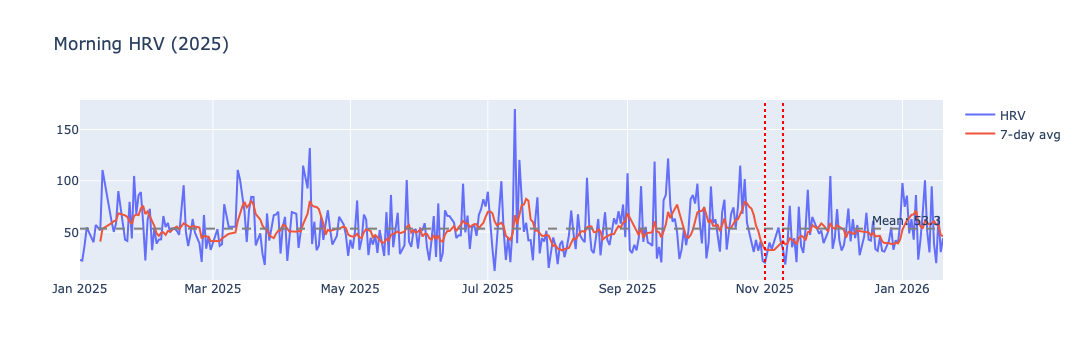

In [2]:
import plotly.graph_objects as go

hrv = pd.read_sql("""
  SELECT date(start_date, '-5 hours') as day, quantity as value
  FROM health_samples 
  WHERE type = 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN'
    AND time(start_date) BETWEEN '04:00' AND '14:00'
    AND start_date >= '2025-01-01'
  ORDER BY start_date
""", conn)

daily = hrv.groupby('day')['value'].first().reset_index()
daily['rolling_7'] = daily['value'].rolling(7).mean()
baseline = daily['value'].mean()

races = ['2025-11-01', '2025-11-09']

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily['day'], y=daily['value'], mode='lines', name='HRV'))
fig.add_trace(go.Scatter(x=daily['day'], y=daily['rolling_7'], mode='lines', name='7-day avg'))
fig.add_hline(y=baseline, line_dash="dash", line_color="gray", annotation_text=f"Mean: {baseline:.1f}")

for race in races:
    fig.add_vline(x=race, line_dash="dot", line_color="red")

fig.update_layout(title='Morning HRV (2025)')
fig.show()

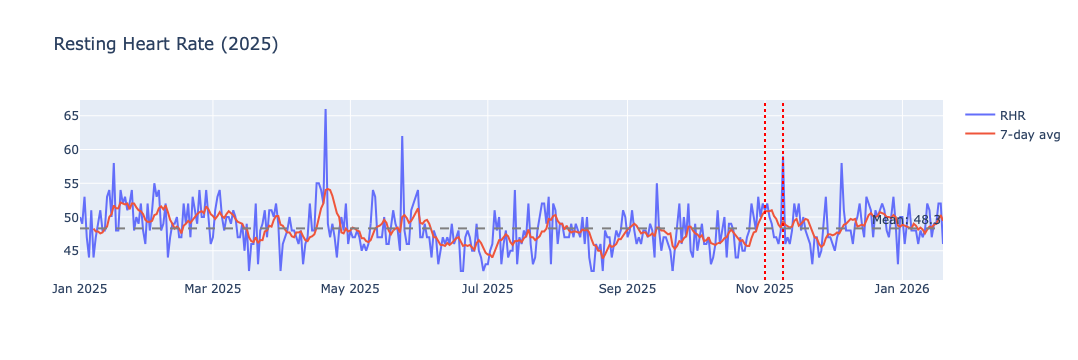

In [3]:
rhr = pd.read_sql("""
  SELECT date(start_date, '-5 hours') as day, quantity as value
  FROM health_samples 
  WHERE type = 'HKQuantityTypeIdentifierRestingHeartRate'
    AND start_date >= '2025-01-01'
  ORDER BY start_date
""", conn)

daily_rhr = rhr.groupby('day')['value'].first().reset_index()
daily_rhr['rolling_7'] = daily_rhr['value'].rolling(7).mean()
baseline_rhr = daily_rhr['value'].mean()

races = ['2025-11-01', '2025-11-09']

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily_rhr['day'], y=daily_rhr['value'], mode='lines', name='RHR'))
fig.add_trace(go.Scatter(x=daily_rhr['day'], y=daily_rhr['rolling_7'], mode='lines', name='7-day avg'))
fig.add_hline(y=baseline_rhr, line_dash="dash", line_color="gray", annotation_text=f"Mean: {baseline_rhr:.1f}")

for race in races:
    fig.add_vline(x=race, line_dash="dot", line_color="red")

fig.update_layout(title='Resting Heart Rate (2025)')
fig.show()

In [4]:
daily_hrv = hrv.groupby('day')['value'].first().reset_index().rename(columns={'value': 'hrv'})
daily_rhr = rhr.groupby('day')['value'].first().reset_index().rename(columns={'value': 'rhr'})

daily_hrv['hrv_7'] = daily_hrv['hrv'].rolling(7).mean()
daily_rhr['rhr_7'] = daily_rhr['rhr'].rolling(7).mean()

merged = daily_hrv.merge(daily_rhr, on='day')
correlation_raw = merged['hrv'].corr(merged['rhr'])
correlation_smoothed = merged['hrv_7'].corr(merged['rhr_7'])

print(f"Daily correlation: {correlation_raw:.3f}")
print(f"7-day avg correlation: {correlation_smoothed:.3f}")

Daily correlation: -0.164
7-day avg correlation: -0.269


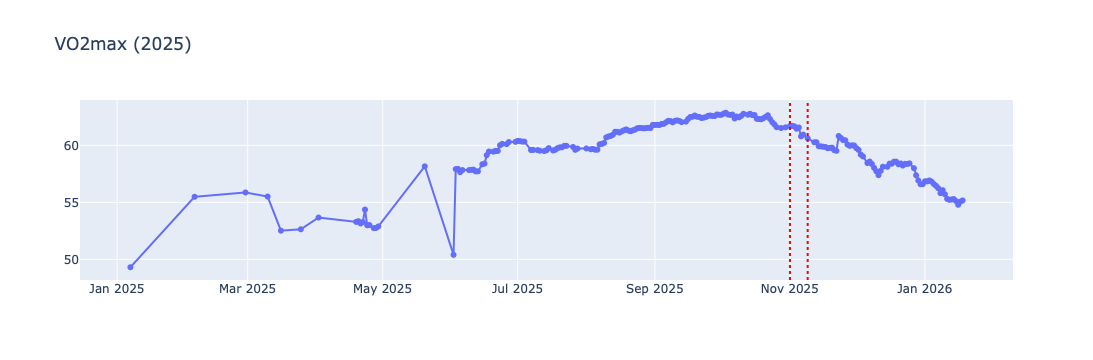

In [6]:
vo2 = pd.read_sql("""
  SELECT date(start_date, '-5 hours') as day, quantity as value
  FROM health_samples 
  WHERE type = 'HKQuantityTypeIdentifierVO2Max'
    AND start_date >= '2025-01-01'
  ORDER BY start_date
""", conn)

daily_vo2 = vo2.groupby('day')['value'].first().reset_index()

races = ['2025-11-01', '2025-11-09']

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily_vo2['day'], y=daily_vo2['value'], mode='lines+markers', name='VO2max'))

for race in races:
    fig.add_vline(x=race, line_dash="dot", line_color="red")

fig.update_layout(title='VO2max (2025)')
fig.show()